In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_targets=1, noise=80, n_informative=1, random_state=2)

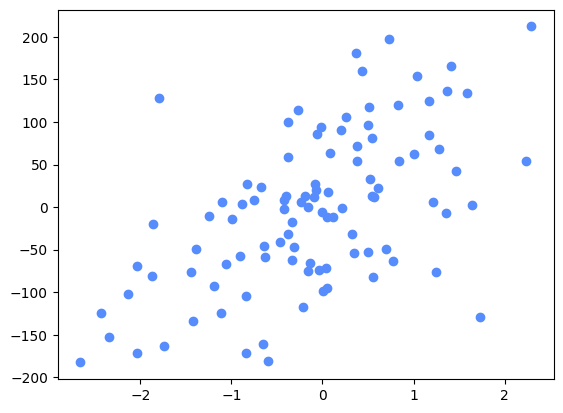

In [3]:
plt.scatter(X,y)

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
print('Coef', model.coef_)
print('Intercept', model.intercept_)


Coef [46.50470223]
Intercept -0.8037859039842044


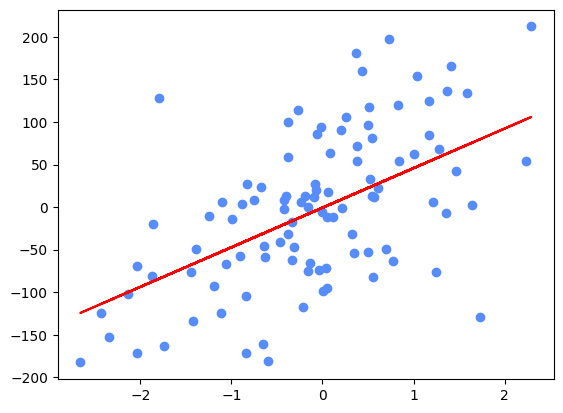

In [8]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red')

In [10]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print('r2', r2)

r2 0.32208406922668


In [13]:
from sklearn.linear_model import Ridge
rr = Ridge(alpha=10)
rr.fit(X_train, y_train)
print('Ridge Coef', rr.coef_)
print('Ridge Intercept', rr.intercept_)


Ridge Coef [41.99503517]
Ridge Intercept -1.4741761953989752


In [14]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[25.87870297]
-0.36259599654633856


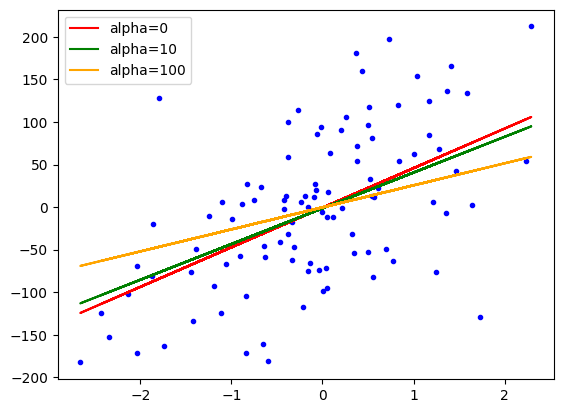

In [15]:
plt.plot(X,y,'b.')
plt.plot(X,model.predict(X),color='red',label='alpha=0')
plt.plot(X,rr.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='orange',label='alpha=100')
plt.legend()

In [16]:
def linear_regression(X,y,alpha=1):
    x_mean = X.mean()
    y_mean = y.mean()

    num = 0
    den = 0

    for i in range(X.shape[0]):
        num = num + (y[i] - y_mean) * (X[i] - x_mean)
        den = den + (X[i] - x_mean) * (X[i] - x_mean)

    m = num/(den + alpha)
    b = y_mean - m*x_mean

    return m,b

In [19]:
class CustomRidge:

    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self,X_train,y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())

        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m,self.b)

    def predict(self,X_test):
        return self.m*X_test + self.b

In [20]:
ridge_scratch = CustomRidge(alpha=10)

In [21]:
ridge_scratch.fit(X_train, y_train)

[41.99503517] [-1.4741762]
